# Portfolio problem

In [22]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":12})
# rc('text', usetex=True)


In [23]:
# mmc2_dir = Path("/", "Users", "patrick", "Datasets", "misdro", "mmc2")
mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
dgp = "DowJones"
returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Index_Returns", header=None)

returns_df

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0.007383,0.012783,0.005208,-0.038285,-0.012098,-0.056079,-0.041475,-0.032967,-0.023324,0.010955,...,0.024652,-0.027021,-0.015650,-0.009319,-0.027835,-0.026883,-0.008618,0.006533,0.051115,0.004274
1,0.014659,0.060496,-0.041451,0.014044,0.008151,0.003959,0.014423,0.039771,0.071641,0.014441,...,-0.108267,0.015873,0.023849,0.041915,0.063393,0.050251,-0.043478,0.012988,0.054975,0.046809
2,0.061602,0.028454,0.005405,0.023102,0.010126,0.011830,0.018950,0.016396,0.036207,0.026693,...,0.067451,0.000000,0.017083,0.107200,0.030769,0.040666,0.018176,0.022436,-0.018046,-0.002036
3,0.157034,0.076217,0.021505,0.029342,0.040078,0.052638,-0.037206,-0.013443,0.016138,0.045055,...,-0.037913,0.023438,0.015268,0.048307,0.067165,0.032176,0.000000,-0.018807,0.004088,0.002040
4,-0.002973,-0.042887,-0.036842,-0.019733,-0.013486,0.009256,-0.057971,0.002724,-0.010582,-0.013267,...,-0.013136,-0.041991,0.007514,0.007680,0.006994,0.008909,-0.040180,-0.022364,0.006101,-0.052846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,0.053573,0.002948,0.053774,0.014542,0.039465,0.034998,0.064654,0.029174,0.023364,0.020403,...,0.022334,-0.000341,0.023586,-0.037993,0.039939,0.003105,0.061533,0.063085,0.104431,0.026879
1359,0.006381,0.041936,-0.024272,0.008619,-0.000660,-0.023225,-0.013680,0.006321,-0.007807,0.029084,...,0.028417,0.049082,0.007722,0.026329,0.027990,-0.000929,0.009661,-0.021790,-0.027284,0.021828
1360,0.033067,0.012977,0.014683,-0.003530,0.027090,0.026488,0.022666,0.017130,0.009056,0.008390,...,0.012139,0.007404,0.018726,0.064299,0.075352,0.024166,0.027531,0.020063,0.043448,0.028452
1361,-0.006798,-0.005941,0.007175,0.008855,0.012866,-0.008401,-0.017532,-0.000749,0.002207,0.002847,...,0.017201,-0.005169,0.008736,-0.052225,-0.033638,-0.002622,-0.015194,-0.005885,-0.007511,0.001896


In [24]:
experiment_dir = Path("/dcs/large/u1508153/misdro/mmd_portfolio")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]
results_df.head()

mean_cost  var_cost  \
uuid                                 replication                        
1bbd2f9f-5659-47fb-85db-df74063368e0 0             0.009859  0.006167   
                                     1             0.000238  0.001421   
fd75c4a2-4bd9-42f8-85d5-606c94a2b382 0             0.010159  0.001519   
                                     1             0.000301  0.001407   
4bb984e7-cfdc-4860-a86a-afa26ff8b8e5 0             0.005740  0.000478   

                                                                                           solution  \
uuid                                 replication                                                      
1bbd2f9f-5659-47fb-85db-df74063368e0 0            [7.691347440093576e-10, 1.3473899087520994e-10...   
                                     1            [2.7718869457327517e-09, 3.005703518452282e-09...   
fd75c4a2-4bd9-42f8-85d5-606c94a2b382 0            [0.025169414591981916, 9.649132219723302e-11, ...   
                                     1            [8.352711035719752e-08, 1.301797693455468e-07,...   
4bb984e7-cfdc-4860-a86a-afa26ff8b8e5 0            [0.0663945728932686, 1.0995604928357556e-10, 0...   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
1bbd2f9f-5659-47fb-85db-df74063368e0 0            0.609827         0.055685   
                                     1            0.278081         0.035062   
fd75c4a2-4bd9-42f8-85d5-606c94a2b382 0            0.608241         0.056160   
                                     1            0.264180         0.036360   
4bb984e7-cfdc-4860-a86a-afa26ff8b8e5 0            0.608194         0.055699   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
1bbd2f9f-5659-47fb-85db-df74063368e0 0                  0.016278  467.537293   
                                     1                  0.016610  351.421116   
fd75c4a2-4bd9-42f8-85d5-606c94a2b382 0                  0.016294  468.034264   
                                     1                  0.015595  349.649235   
4bb984e7-cfdc-4860-a86a-afa26ff8b8e5 0                  0.016257  469.165389   

                                                  setup_time  \
uuid                                 replication               
1bbd2f9f-5659-47fb-85db-df74063368e0 0                   NaN   
                                     1                   NaN   
fd75c4a2-4bd9-42f8-85d5-606c94a2b382 0                   NaN   
                                     1                   NaN   
4bb984e7-cfdc-4860-a86a-afa26ff8b8e5 0                   NaN   

                                                  log_partition_constant  \
uuid                                 replication                           
1bbd2f9f-5659-47fb-85db-df74063368e0 0                               0.0   
                                     1                               0.0   
fd75c4a2-4bd9-42f8-85d5-606c94a2b382 0                               0.0   
                                     1                               0.0   
4bb984e7-cfdc-4860-a86a-afa26ff8b8e5 0                               0.0   

                                                                                out_of_sample_costs  \
uuid                                 replication                                                      
1bbd2f9f-5659-47fb-85db-df74063368e0 0            [-0.029542093045750714, 0.017250123844273643, ...   
                                     1            [-0.041213185711574306, -0.005721514136785104,...   
fd75c4a2-4bd9-42f8-85d5-606c94a2b382 0            [-0.008257008633974668, 0.002551559945980217, ...   
                                     1            [-0.041064815008067745, -0.0055655453258230915...   
4bb984e7-cfdc-4860-a86a-afa26ff8b8e5 0            [-0.008414035374258846, 0.008671321868029122, ...  

In [25]:
experiment_dir = Path("/dcs/large/u1508153/misdro/kl_portfolio")
assert experiment_dir.exists()
kl_results_df = pd.read_csv(experiment_dir / "results.csv")
# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]
kl_results_df = kl_results_df.loc[kl_results_df["replication"] < 2].set_index(["uuid", "replication"])
results_df = pd.concat([results_df, kl_results_df])
results_df["algorithm"].unique().tolist()

['dro_bas_mmd', 'empirical_mmd', 'kl_dro_bas', 'kl_bdro']

In [26]:
agg_df = get_agg_df(results_df, ["algorithm","dgp", "epsilon", "num_posterior_samples"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:303: FutureWarning: The provided callable <function mean at 0x7fa9fc10e340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:303: FutureWarning: The provided callable <function var at 0x7fa9fc10e5c0> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:303: FutureWarning: The provided callable <function mean at 0x7fa9fc10e340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis

out_of_sample_mean  \
algorithm   dgp      epsilon num_posterior_samples                       
dro_bas_mmd DowJones 0.001   90                               0.005049   
                     0.005   90                               0.005230   
                     0.010   90                               0.004624   
                     0.050   90                               0.005126   
                     0.100   90                               0.003768   
...                                                                ...   
kl_dro_bas  DowJones 8.000   1                                0.001872   
                     8.500   1                                0.001863   
                     9.000   1                                0.001854   
                     9.500   1                                0.001847   
                     10.000  1                                0.001840   

                                                    out_of_sample_mean_of_vars  \
algorithm   dgp      epsilon num_posterior_samples                               
dro_bas_mmd DowJones 0.001   90                                       0.003794   
                     0.005   90                                       0.001463   
                     0.010   90                                       0.000550   
                     0.050   90                                       0.000389   
                     0.100   90                                       0.000370   
...                                                                        ...   
kl_dro_bas  DowJones 8.000   1                                        0.000210   
                     8.500   1                                        0.000210   
                     9.000   1                                        0.000210   
                     9.500   1                                        0.000210   
                     10.000  1                                        0.000210   

                                                    out_of_sample_var_of_means  \
algorithm   dgp      epsilon num_posterior_samples                               
dro_bas_mmd DowJones 0.001   90                                   4.628520e-05   
                     0.005   90                                   4.859087e-05   
                     0.010   90                                   2.487845e-06   
                     0.050   90                                   4.898631e-07   
                     0.100   90                                   8.601176e-08   
...                                                                        ...   
kl_dro_bas  DowJones 8.000   1                                    1.541171e-07   
                     8.500   1                                    1.547404e-07   
                     9.000   1                                    1.552568e-07   
                     9.500   1                                    1.557392e-07   
                     10.000  1                                    1.561574e-07   

                                                    mean_solve_time  \
algorithm   dgp      epsilon num_posterior_samples                    
dro_bas_mmd DowJones 0.001   90                          409.479204   
                     0.005   90                          408.841749   
                     0.010   90                          399.813669   
                     0.050   90                          406.945198   
                     0.100   90                          406.802874   
...                                                             ...   
kl_dro_bas  DowJones 8.000   1                             0.072721   
                     8.500   1                             0.073985   
                     9.000   1                             0.069314   
                     9.500   1                             0.068936   
                     10.000  1                             0.069141   

                               

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


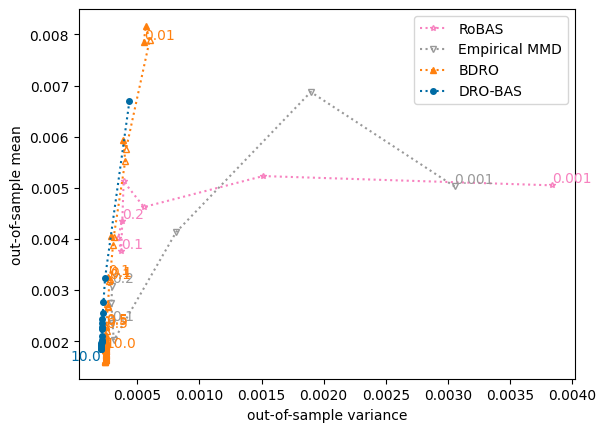

In [27]:
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")
fig, ax = plt.subplots()
NUM_POSTERIOR_SAMPLES = 5
# df = agg_df.loc[(posterior_sr == 1) | (posterior_sr == NUM_POSTERIOR_SAMPLES)]
df = agg_df
# df = df.loc[:,:,0.1:]
df.loc[:, "is_maximise_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
gb = df.groupby("algorithm")
for algorithm, group_df in gb:
    mean_variance_plot(ax, group_df, is_labelled=True, offset=0, alpha=1.0, **algorithm_style(algorithm), pareto_front_col="is_maximise_pareto_front")
ax.legend()
ax.set_xlabel("out-of-sample variance")
ax.set_ylabel("out-of-sample mean")
# ax.set_xlim(agg_df["out_of_sample_var"].min(), agg_df["out_of_sample_var"].max())
# ax.set_ylim(agg_df["out_of_sample_mean"].min(), agg_df["out_of_sample_mean"].min())
fig.show()

In [28]:
num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
num_stocks = int(len(returns_df.columns))

In [29]:
week_cols = [f"week_{i}" for i in range(OUT_OF_SAMPLE_TIME_WINDOW)]
stock_cols = [f"stock_{i}" for i in range(num_stocks)]
dro_returns = {week: [] for week in week_cols}
for stock in stock_cols:
    dro_returns[stock] = []
dro_returns["uuid"] = []
dro_returns["replication"] = []
for idx, row in results_df[["out_of_sample_costs", "solution"]].iterrows():
    uuid, replication = idx
    str_cost, str_solution = row["out_of_sample_costs"], row["solution"]
    if str_cost == "[]":
        costs = [np.nan for _ in range(OUT_OF_SAMPLE_TIME_WINDOW)]
    else:
        costs = [float(x) for x in str_cost.strip('[]').split(',')]
    solution = [float(x) for x in str_solution.strip('[]').split(',')]
    dro_returns["uuid"].append(uuid)
    dro_returns["replication"].append(replication)
    for i, week in enumerate(week_cols):
        dro_returns[week].append(costs[i])
    for i, stock in enumerate(stock_cols):
        dro_returns[stock].append(solution[i])

dro_returns_df = pd.DataFrame(dro_returns).set_index(["uuid", "replication"])
dro_returns_df

ValueError: could not convert string to float: 'inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf\n inf inf inf inf inf inf inf inf inf inf'

In [8]:
# join the dataframes, the sort and groupby
results_df = results_df.join(dro_returns_df)
results_df

mean_cost  var_cost  \
uuid                                 replication                        
1bbd2f9f-5659-47fb-85db-df74063368e0 0             0.009859  0.006167   
                                     1             0.000238  0.001421   
fd75c4a2-4bd9-42f8-85d5-606c94a2b382 0             0.010159  0.001519   
                                     1             0.000301  0.001407   
4bb984e7-cfdc-4860-a86a-afa26ff8b8e5 0             0.005740  0.000478   
                                     1             0.003509  0.000622   
0fccd472-44ca-4005-a0c6-a7cb81e2747b 0             0.004631  0.000192   
                                     1             0.005621  0.000587   
b236e9f3-5bb6-45fc-b378-029d807b0ebb 0             0.003975  0.000206   
                                     1             0.003561  0.000535   
bc95899d-078c-4fb5-868b-3075b78cc9a3 0             0.003341  0.000214   
                                     1             0.004697  0.000478   
0c4d0417-3ed3-4952-8ec7-d32412df70dc 0             0.003914  0.000197   
                                     1             0.004777  0.000549   
e0c22d57-b5f2-430e-a9c4-851eaf6b95ca 0             0.011541  0.003906   
                                     1            -0.001486  0.002031   
02e66fce-9e16-466d-94de-56358451672c 0             0.008769  0.002629   
                                     1             0.004980  0.001149   
adc56997-3050-4681-bcfe-92f5eee3f7b4 0             0.003963  0.000751   
                                     1             0.004307  0.000874   
3b24af41-caa7-4e14-a2bf-c65e3c8377db 0             0.001416  0.000206   
                                     1             0.002617  0.000414   
8a397c49-a2e9-4554-aa32-8edfa882bb40 0             0.002167  0.000186   
                                     1             0.002557  0.000413   
255fea9b-0df4-4efc-b3db-5eaf593f9d44 0             0.002624  0.000189   
                                     1             0.002887  0.000394   
fb6ed04e-176e-4c1a-9c0d-c1d93104b7c6 0             0.002740  0.000181   
                                     1             0.003435  0.000413   

                                                                                           solution  \
uuid                                 replication                                                      
1bbd2f9f-5659-47fb-85db-df74063368e0 0            [7.691347440093576e-10, 1.3473899087520994e-10...   
                                     1            [2.7718869457327517e-09, 3.005703518452282e-09...   
fd75c4a2-4bd9-42f8-85d5-606c94a2b382 0            [0.025169414591981916, 9.649132219723302e-11, ...   
                                     1            [8.352711035719752e-08, 1.301797693455468e-07,...   
4bb984e7-cfdc-4860-a86a-afa26ff8b8e5 0            [0.0663945728932686, 1.0995604928357556e-10, 0...   
                                     1            [3.692165157959478e-08, 0.048127126592024214, ...   
0fccd472-44ca-4005-a0c6-a7cb81e2747b 0            [0.04429208769677609, 0.004777311107531628, 0....   
                                     1            [0.028712825223650613, 0.02475497677254383, 2....   
b236e9f3-5bb6-45fc-b378-029d807b0ebb 0            [0.0423539333980032, 2.3518628193686118e-08, 0...   
                                     1            [0.025053760655616604, 0.01689670641930815, 4....   
bc95899d-078c-4fb5-868b-3075b78cc9a3 0            [0.021332754043393378, 0.02985240583621951, 0....   
                                     1            [0.030198424275004597, 0.02588511440932363, 0....   
0c4d0417-3ed3-4952-8ec7-d32412df70dc 0            [0.04046675850943096, 0.01522202929184883, 0.0...   
                                     1            [0.020004766609771164, 0.026496600043580502, 0...   
e0c22d57-b5f2-430e-a9c4-851eaf6b95ca 0            [1.984564561240952e-09, 1.4269696425508006e-09...   
                                     1            [4.151703196608293e-08, 2.5031687695534595e-08...   
02e66

In [9]:
results_df = results_df.loc[(results_df["num_posterior_samples"] == NUM_POSTERIOR_SAMPLES) | (results_df["num_posterior_samples"] == 1)]
gb = results_df.groupby(["algorithm", "epsilon", "num_posterior_samples"])

In [10]:
for (algorithm, epsilon, num_posterior_samples), group_df in gb:
    dro_bas_returns = group_df[week_cols].values.flatten()
    print(algorithm, epsilon, np.sum(dro_bas_returns))

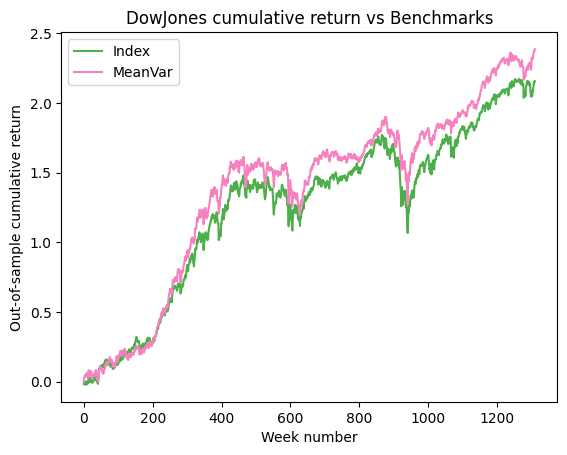

In [11]:
# dro_bas_returns = solution_returns.flatten()
bdro_labelled = False
dro_bas_labelled = False
for (algorithm, epsilon, num_posterior_samples), group_df in gb:
    dro_returns = group_df[week_cols].values.flatten()
    if not dro_bas_labelled and algorithm == "kl_dro_bas":
        label = algorithm
        dro_bas_labelled = True
    elif not bdro_labelled and algorithm == "kl_bdro":
        label = algorithm
        bdro_labelled = True
    else:
        label='_nolegend_'
    plt.plot(np.cumsum(dro_returns), label=label, alpha=0.3, color=AlgorithmColor[algorithm].value)
CB_color_cycle = ['#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
plt.plot(np.cumsum(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:].values), label="Index", color=CB_color_cycle[0])
# for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:

for i, baseline_model in enumerate(["MeanVar"]):
    baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    plt.plot(np.cumsum(baseline_returns), label=baseline_model, color=CB_color_cycle[i+1])

plt.xlabel("Week number")
plt.ylabel("Out-of-sample cumulative return")
plt.title(dgp + r" cumulative return vs Benchmarks")
plt.legend()
plt.show()

In [12]:

for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
    # print(algorithm, epsilon, np.mean(group_df[stock_cols].values), np.var(group_df[stock_cols].values))
    print(algorithm, epsilon, np.mean(group_df[stock_cols].values, axis=0))